In [362]:
import os
import numpy as np
import pandas as pd
from datetime import datetime
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.models import Model
from sklearn.model_selection import train_test_split, KFold
import matplotlib.pyplot as plt
from tensorflow.keras.callbacks import EarlyStopping
import json

In [363]:
stage = "river"

### Reading and compacting dfs

In [364]:
compact = False

In [365]:
# Iterate over files in dfs/*.parquet and combine to one df
dfs = []

read = []
for file in os.listdir('dfs'):
    if file.endswith('.parquet'):
        read.append(file)
        df = pd.read_parquet(f"dfs/{file}")
        dfs.append(df)

raw_df = pd.concat(dfs, ignore_index=True)

if compact and len(dfs) > 0:
    print("Compacintg dfs")
    # Move read files to trash and write combined df to dfs/combined_{timestamp}.parquet
    trash = 'dfs/trash'
    for f in read:
        os.rename(f'dfs/{f}', f'{trash}/{f}')

    timestamp = datetime.now().strftime("%Y%m%d%H%M%S")
    raw_df.to_parquet(f'dfs/compacted_{timestamp}.parquet')

raw_df

,prob_P_has_hand_0,prob_P_has_hand_1,prob_P_has_hand_2,prob_P_has_hand_3,prob_P_has_hand_4,prob_P_has_hand_5,prob_P_has_hand_6,prob_P_has_hand_7,prob_P_has_hand_8,prob_P_has_hand_9,...,player_bet_in_stage,player_bet_in_game,opponent_bet_in_stage,opponent_bet_in_game,player_turn,player_has_bet,opponent_has_bet,pot,game_size,stage
0,0.000949,0.001175,0.000867,0.001118,0.000547,0.000335,0.000376,0.000019,0.000609,0.000970,...,0,224,65,289,True,False,True,513,1496,river
1,0.000953,0.000382,0.001230,0.000696,0.000345,0.000526,0.000573,0.000548,0.000306,0.001121,...,0,216,47,263,True,False,True,479,1431,river
2,0.000599,0.000679,0.000011,0.001274,0.000049,0.000294,0.001106,0.000297,0.000436,0.000799,...,0,406,151,557,True,False,True,963,1930,river
3,0.000326,0.000179,0.000722,0.000766,0.000419,0.000994,0.000819,0.001090,0.000313,0.000129,...,0,389,77,466,True,False,True,855,2236,river
4,0.000474,0.001348,0.000230,0.000934,0.000944,0.001230,0.000413,0.000513,0.000326,0.000888,...,0,434,63,497,True,False,True,931,2612,river
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
406,0.000606,0.000134,0.000044,0.001506,0.000911,0.000148,0.000991,0.001004,0.001256,0.001168,...,108,226,198,316,True,True,True,542,2083,river
407,0.001264,0.000755,0.000916,0.000563,0.000142,0.000096,0.000540,0.001188,0.001201,0.000580,...,0,384,189,573,True,False,True,957,2419,river
408,0.000171,0.000525,0.000313,0.001181,0.000674,0.000659,0.001246,0.000157,0.000905,0.000312,...,253,635,515,897,True,True,True,1532,2894,river
409,0.000262,0.000291,0.000953,0.001247,0.000777,0.000546,0.001030,0.001214,0.001298,0.000451,...,0,280,0,280,True,False,False,560,2284,river


In [366]:
df = raw_df[raw_df["stage"] == stage]
df = df.drop(columns=["stage"])
df

,prob_P_has_hand_0,prob_P_has_hand_1,prob_P_has_hand_2,prob_P_has_hand_3,prob_P_has_hand_4,prob_P_has_hand_5,prob_P_has_hand_6,prob_P_has_hand_7,prob_P_has_hand_8,prob_P_has_hand_9,...,public_card_51,player_bet_in_stage,player_bet_in_game,opponent_bet_in_stage,opponent_bet_in_game,player_turn,player_has_bet,opponent_has_bet,pot,game_size
0,0.000949,0.001175,0.000867,0.001118,0.000547,0.000335,0.000376,0.000019,0.000609,0.000970,...,0.0,0,224,65,289,True,False,True,513,1496
1,0.000953,0.000382,0.001230,0.000696,0.000345,0.000526,0.000573,0.000548,0.000306,0.001121,...,0.0,0,216,47,263,True,False,True,479,1431
2,0.000599,0.000679,0.000011,0.001274,0.000049,0.000294,0.001106,0.000297,0.000436,0.000799,...,0.0,0,406,151,557,True,False,True,963,1930
3,0.000326,0.000179,0.000722,0.000766,0.000419,0.000994,0.000819,0.001090,0.000313,0.000129,...,0.0,0,389,77,466,True,False,True,855,2236
4,0.000474,0.001348,0.000230,0.000934,0.000944,0.001230,0.000413,0.000513,0.000326,0.000888,...,0.0,0,434,63,497,True,False,True,931,2612
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
406,0.000606,0.000134,0.000044,0.001506,0.000911,0.000148,0.000991,0.001004,0.001256,0.001168,...,0.0,108,226,198,316,True,True,True,542,2083
407,0.001264,0.000755,0.000916,0.000563,0.000142,0.000096,0.000540,0.001188,0.001201,0.000580,...,0.0,0,384,189,573,True,False,True,957,2419
408,0.000171,0.000525,0.000313,0.001181,0.000674,0.000659,0.001246,0.000157,0.000905,0.000312,...,0.0,253,635,515,897,True,True,True,1532,2894
409,0.000262,0.000291,0.000953,0.001247,0.000777,0.000546,0.001030,0.001214,0.001298,0.000451,...,0.0,0,280,0,280,True,False,False,560,2284


In [367]:
# Show all types of columns:
list(sorted(set(["_".join(col.split("_")[0:2]) for col in df.columns])))

['game_size',
 'opponent_bet',
 'opponent_has',
 'player_bet',
 'player_has',
 'player_turn',
 'pot',
 'prob_O',
 'prob_P',
 'public_card',
 'value_of']

### Preprocessing

In [368]:
# Divide all bets by game_size
bet_columns = [
    "player_bet_in_stage",
    "player_bet_in_game",
    "opponent_bet_in_stage",
    "opponent_bet_in_game",
    "pot",
]

def scale_bets(df):
    df[bet_columns] = df[bet_columns].div(df["game_size"], axis=0)
    return df


scale_bets(df)
df[bet_columns]

,player_bet_in_stage,player_bet_in_game,opponent_bet_in_stage,opponent_bet_in_game,pot
0,0.000000,0.149733,0.043449,0.193182,0.342914
1,0.000000,0.150943,0.032844,0.183788,0.334731
2,0.000000,0.210363,0.078238,0.288601,0.498964
3,0.000000,0.173971,0.034436,0.208408,0.382379
4,0.000000,0.166156,0.024119,0.190276,0.356432
...,...,...,...,...,...
406,0.051848,0.108497,0.095055,0.151704,0.260202
407,0.000000,0.158743,0.078131,0.236875,0.395618
408,0.087422,0.219419,0.177954,0.309952,0.529371
409,0.000000,0.122592,0.000000,0.122592,0.245184


In [369]:
# Scale range features so that the mean becomes 0 and the standard deviation becomes 1
range_columns = [col for col in df.columns if col.startswith("prob_")]
def scale_ranges(df, training_mean, training_sd):
    df[range_columns] = (df[range_columns] - training_mean) / training_sd
    return df

def get_training_range_mean_and_sd(df):
    return df[range_columns].to_numpy().mean(), df[range_columns].to_numpy().std()

def revert_range_scaling(df, training_mean, training_sd):
    df[range_columns] = df[range_columns] * training_sd + training_mean
    return df

mean_training_range_val, sd_training_range_val = get_training_range_mean_and_sd(df)
scale_ranges(df, mean_training_range_val, sd_training_range_val)
print("Original mean and sd of range features:")
print(mean_training_range_val, sd_training_range_val)
print("Mean and sd of range features after scaling:")
print(df[range_columns].to_numpy().mean(), df[range_columns].to_numpy().std())
df[range_columns]

Original mean and sd of range features:
0.0007541478129713427 0.0004349598366742086
Mean and sd of range features after scaling:
-8.12180988449678e-16 1.0000000000000002


,prob_P_has_hand_0,prob_P_has_hand_1,prob_P_has_hand_2,prob_P_has_hand_3,prob_P_has_hand_4,prob_P_has_hand_5,prob_P_has_hand_6,prob_P_has_hand_7,prob_P_has_hand_8,prob_P_has_hand_9,...,prob_O_has_hand_1316,prob_O_has_hand_1317,prob_O_has_hand_1318,prob_O_has_hand_1319,prob_O_has_hand_1320,prob_O_has_hand_1321,prob_O_has_hand_1322,prob_O_has_hand_1323,prob_O_has_hand_1324,prob_O_has_hand_1325
0,0.447361,0.967443,0.259714,0.837534,-0.476236,-0.963507,-0.868700,-1.690105,-0.332650,0.495930,...,0.602780,0.587351,0.073543,-1.345815,-1.720405,0.248033,-1.280872,-1.584527,-0.437533,1.292588
1,0.457353,-0.856211,1.094126,-0.134537,-0.939729,-0.523877,-0.416606,-0.472835,-1.029732,0.844189,...,-0.318640,-0.480446,0.571784,1.750061,-0.622301,0.203070,-0.352325,1.506256,-0.923576,-1.301620
2,-0.357802,-0.172514,-1.708030,1.195581,-1.621351,-1.058323,0.809722,-1.050767,-0.731411,0.102875,...,-0.899311,1.104494,1.482679,-0.360233,0.554062,0.343531,0.903627,0.752752,0.110138,-1.638938
3,-0.984309,-1.323053,-0.074647,0.026518,-0.770025,0.551815,0.148113,0.772825,-1.014485,-1.437083,...,0.934729,-1.534194,-0.739808,0.233479,-0.371454,-1.613776,-0.295386,0.021571,1.282035,-0.660864
4,-0.643785,1.364510,-1.205776,0.412873,0.437195,1.093656,-0.784476,-0.555537,-0.984102,0.306589,...,0.470081,-1.387888,-1.642149,1.524540,0.433767,-0.564081,-0.773407,-0.678542,-0.498236,0.080003
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
406,-0.341362,-1.425719,-1.632695,1.727945,0.360820,-1.393203,0.544665,0.575173,1.153687,0.951710,...,-1.209881,0.761474,-0.054134,0.783540,1.297156,-0.250139,0.557432,-0.070851,1.246639,1.108235
407,1.171932,0.002053,0.371733,-0.438672,-1.407511,-1.513255,-0.491886,0.997836,1.026623,-0.400479,...,-0.463440,0.254903,1.376118,-0.592235,-1.419322,0.968551,0.171169,-0.100474,-0.134179,-1.192754
408,-1.340049,-0.526919,-1.014774,0.980214,-0.183643,-0.219448,1.130420,-1.374021,0.345805,-1.015730,...,-1.394649,0.266373,-0.997794,0.316838,0.245512,-0.482037,1.067821,-0.162834,-1.716047,-0.921025
409,-1.131482,-1.064323,0.456185,1.132975,0.051840,-0.478529,0.633880,1.057451,1.250657,-0.696395,...,1.305247,0.981189,0.678441,0.865375,-0.528024,1.153713,1.266954,1.020502,1.527709,1.581603


In [370]:
# Scale node values (target variable) so that the mean becomes 0 and the standard deviation becomes 1
value_columns = [col for col in df.columns if col.startswith("value_")]

"""
# Commented out, because we probably don't need it (target is already at scale [-1, 1])
def scale_values(df, training_mean, training_sd):
    df[value_columns] = (df[value_columns] - training_mean) / training_sd
    return df


def get_training_target_mean_and_sd(df):
    return df[value_columns].to_numpy().mean(), df[value_columns].to_numpy().std()


def revert_value_scaling(arr: np.array, training_mean, training_sd):
    return arr * training_sd + training_mean


mean_training_value_val, sd_training_value_val = get_training_target_mean_and_sd(df)
orig_values = df[value_columns]
scale_values(df, mean_training_value_val, sd_training_value_val)
print("Original mean and sd of values:")
print(orig_values.to_numpy().mean())
print(orig_values.to_numpy().std())
print("New mean and sd of values:")
print(df[value_columns].to_numpy().mean())
print(df[value_columns].to_numpy().std())
# Check revert function
assert np.allclose(
    revert_value_scaling(df, mean_training_value_val, sd_training_value_val)[
        value_columns
    ].to_numpy(),
    orig_values.to_numpy(),
)
df[value_columns] """
print("Mean of target variable:", df[value_columns].to_numpy().mean())
print("SD of target variable:", df[value_columns].to_numpy().std())
print("Min of target variable:", df[value_columns].to_numpy().min())
print("Max of target variable:", df[value_columns].to_numpy().max())
df[value_columns]

Mean of target variable: -0.0014427576792721013
SD of target variable: 0.12076726245034895
Min of target variable: -0.3554668813288401
Max of target variable: 0.5294530942395186


,value_of_hand_0,value_of_hand_1,value_of_hand_2,value_of_hand_3,value_of_hand_4,value_of_hand_5,value_of_hand_6,value_of_hand_7,value_of_hand_8,value_of_hand_9,...,value_of_hand_1316,value_of_hand_1317,value_of_hand_1318,value_of_hand_1319,value_of_hand_1320,value_of_hand_1321,value_of_hand_1322,value_of_hand_1323,value_of_hand_1324,value_of_hand_1325
0,-0.081638,-0.000498,-0.028550,-0.090864,0.070579,0.067363,0.060463,0.050083,0.000000,0.034855,...,-0.061026,0.024404,0.010037,0.001629,-0.062474,-0.065114,-0.067324,0.008741,0.000099,-0.002278
1,0.241291,-0.000329,0.202978,0.056633,0.032012,0.016464,0.005828,0.000817,-0.052290,-0.020656,...,0.000000,0.000000,-0.041838,-0.064753,0.000000,0.000000,0.000000,0.000000,0.000000,-0.047671
2,0.001929,0.379400,0.334204,-0.000464,-0.000783,-0.097363,-0.000641,0.000000,0.263324,0.077466,...,-0.000957,-0.000996,-0.000999,-0.017562,0.061099,0.032305,0.010830,0.025084,0.005923,0.005152
3,0.072178,0.000316,0.066442,-0.000460,0.059202,-0.010708,0.048682,0.032374,0.018234,0.005971,...,0.010835,0.002015,-0.045242,-0.066926,0.000951,-0.048285,-0.069988,-0.051346,-0.072479,-0.092398
4,0.000000,0.253612,0.221163,0.104365,-0.000647,0.000000,-0.030952,0.076358,0.051061,-0.051772,...,-0.092373,0.000000,0.016166,0.002134,0.000000,0.015301,0.002531,0.000000,0.000000,0.002380
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
406,-0.065529,-0.073302,0.000000,0.000000,-0.079839,-0.087219,0.000000,-0.094099,-0.101385,-0.109734,...,0.137327,0.116258,0.095871,-0.026285,0.114424,0.094035,-0.027785,0.089407,-0.029130,-0.029462
407,0.019414,-0.000720,0.020095,0.019561,0.017655,-0.000759,-0.005162,-0.008029,0.015384,0.013418,...,-0.000522,-0.000502,-0.000530,-0.000580,-0.013092,0.047680,0.031739,0.046899,0.031036,0.027667
408,0.345951,0.344209,-0.026936,0.312363,0.264424,-0.058003,0.204619,0.000000,0.134436,-0.133568,...,-0.111460,0.000000,-0.221216,-0.114253,0.000000,-0.186473,-0.236552,0.000000,0.000000,-0.191652
409,-0.000602,-0.000032,-0.000031,-0.000032,-0.000032,-0.000033,-0.006720,-0.000734,-0.000820,-0.001093,...,-0.006043,-0.006186,-0.006406,-0.006517,-0.006129,-0.006348,-0.006460,-0.006431,-0.006542,-0.006653


In [371]:
# Make boolean features 0 or 1
def encode_bools(df):
    bool_columns = [
        "player_turn",
        "player_has_bet",
        "opponent_has_bet",
    ]
    df[bool_columns] = df[bool_columns].astype(int)
    return df

df = encode_bools(df)
df

,prob_P_has_hand_0,prob_P_has_hand_1,prob_P_has_hand_2,prob_P_has_hand_3,prob_P_has_hand_4,prob_P_has_hand_5,prob_P_has_hand_6,prob_P_has_hand_7,prob_P_has_hand_8,prob_P_has_hand_9,...,public_card_51,player_bet_in_stage,player_bet_in_game,opponent_bet_in_stage,opponent_bet_in_game,player_turn,player_has_bet,opponent_has_bet,pot,game_size
0,0.447361,0.967443,0.259714,0.837534,-0.476236,-0.963507,-0.868700,-1.690105,-0.332650,0.495930,...,0.0,0.000000,0.149733,0.043449,0.193182,1,0,1,0.342914,1496
1,0.457353,-0.856211,1.094126,-0.134537,-0.939729,-0.523877,-0.416606,-0.472835,-1.029732,0.844189,...,0.0,0.000000,0.150943,0.032844,0.183788,1,0,1,0.334731,1431
2,-0.357802,-0.172514,-1.708030,1.195581,-1.621351,-1.058323,0.809722,-1.050767,-0.731411,0.102875,...,0.0,0.000000,0.210363,0.078238,0.288601,1,0,1,0.498964,1930
3,-0.984309,-1.323053,-0.074647,0.026518,-0.770025,0.551815,0.148113,0.772825,-1.014485,-1.437083,...,0.0,0.000000,0.173971,0.034436,0.208408,1,0,1,0.382379,2236
4,-0.643785,1.364510,-1.205776,0.412873,0.437195,1.093656,-0.784476,-0.555537,-0.984102,0.306589,...,0.0,0.000000,0.166156,0.024119,0.190276,1,0,1,0.356432,2612
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
406,-0.341362,-1.425719,-1.632695,1.727945,0.360820,-1.393203,0.544665,0.575173,1.153687,0.951710,...,0.0,0.051848,0.108497,0.095055,0.151704,1,1,1,0.260202,2083
407,1.171932,0.002053,0.371733,-0.438672,-1.407511,-1.513255,-0.491886,0.997836,1.026623,-0.400479,...,0.0,0.000000,0.158743,0.078131,0.236875,1,0,1,0.395618,2419
408,-1.340049,-0.526919,-1.014774,0.980214,-0.183643,-0.219448,1.130420,-1.374021,0.345805,-1.015730,...,0.0,0.087422,0.219419,0.177954,0.309952,1,1,1,0.529371,2894
409,-1.131482,-1.064323,0.456185,1.132975,0.051840,-0.478529,0.633880,1.057451,1.250657,-0.696395,...,0.0,0.000000,0.122592,0.000000,0.122592,1,0,0,0.245184,2284


In [372]:
# Drop game_size column
df = df.drop(columns=["game_size"])
df

,prob_P_has_hand_0,prob_P_has_hand_1,prob_P_has_hand_2,prob_P_has_hand_3,prob_P_has_hand_4,prob_P_has_hand_5,prob_P_has_hand_6,prob_P_has_hand_7,prob_P_has_hand_8,prob_P_has_hand_9,...,public_card_50,public_card_51,player_bet_in_stage,player_bet_in_game,opponent_bet_in_stage,opponent_bet_in_game,player_turn,player_has_bet,opponent_has_bet,pot
0,0.447361,0.967443,0.259714,0.837534,-0.476236,-0.963507,-0.868700,-1.690105,-0.332650,0.495930,...,0.0,0.0,0.000000,0.149733,0.043449,0.193182,1,0,1,0.342914
1,0.457353,-0.856211,1.094126,-0.134537,-0.939729,-0.523877,-0.416606,-0.472835,-1.029732,0.844189,...,0.0,0.0,0.000000,0.150943,0.032844,0.183788,1,0,1,0.334731
2,-0.357802,-0.172514,-1.708030,1.195581,-1.621351,-1.058323,0.809722,-1.050767,-0.731411,0.102875,...,0.0,0.0,0.000000,0.210363,0.078238,0.288601,1,0,1,0.498964
3,-0.984309,-1.323053,-0.074647,0.026518,-0.770025,0.551815,0.148113,0.772825,-1.014485,-1.437083,...,0.0,0.0,0.000000,0.173971,0.034436,0.208408,1,0,1,0.382379
4,-0.643785,1.364510,-1.205776,0.412873,0.437195,1.093656,-0.784476,-0.555537,-0.984102,0.306589,...,0.0,0.0,0.000000,0.166156,0.024119,0.190276,1,0,1,0.356432
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
406,-0.341362,-1.425719,-1.632695,1.727945,0.360820,-1.393203,0.544665,0.575173,1.153687,0.951710,...,0.0,0.0,0.051848,0.108497,0.095055,0.151704,1,1,1,0.260202
407,1.171932,0.002053,0.371733,-0.438672,-1.407511,-1.513255,-0.491886,0.997836,1.026623,-0.400479,...,0.0,0.0,0.000000,0.158743,0.078131,0.236875,1,0,1,0.395618
408,-1.340049,-0.526919,-1.014774,0.980214,-0.183643,-0.219448,1.130420,-1.374021,0.345805,-1.015730,...,0.0,0.0,0.087422,0.219419,0.177954,0.309952,1,1,1,0.529371
409,-1.131482,-1.064323,0.456185,1.132975,0.051840,-0.478529,0.633880,1.057451,1.250657,-0.696395,...,0.0,0.0,0.000000,0.122592,0.000000,0.122592,1,0,0,0.245184


### Data validation

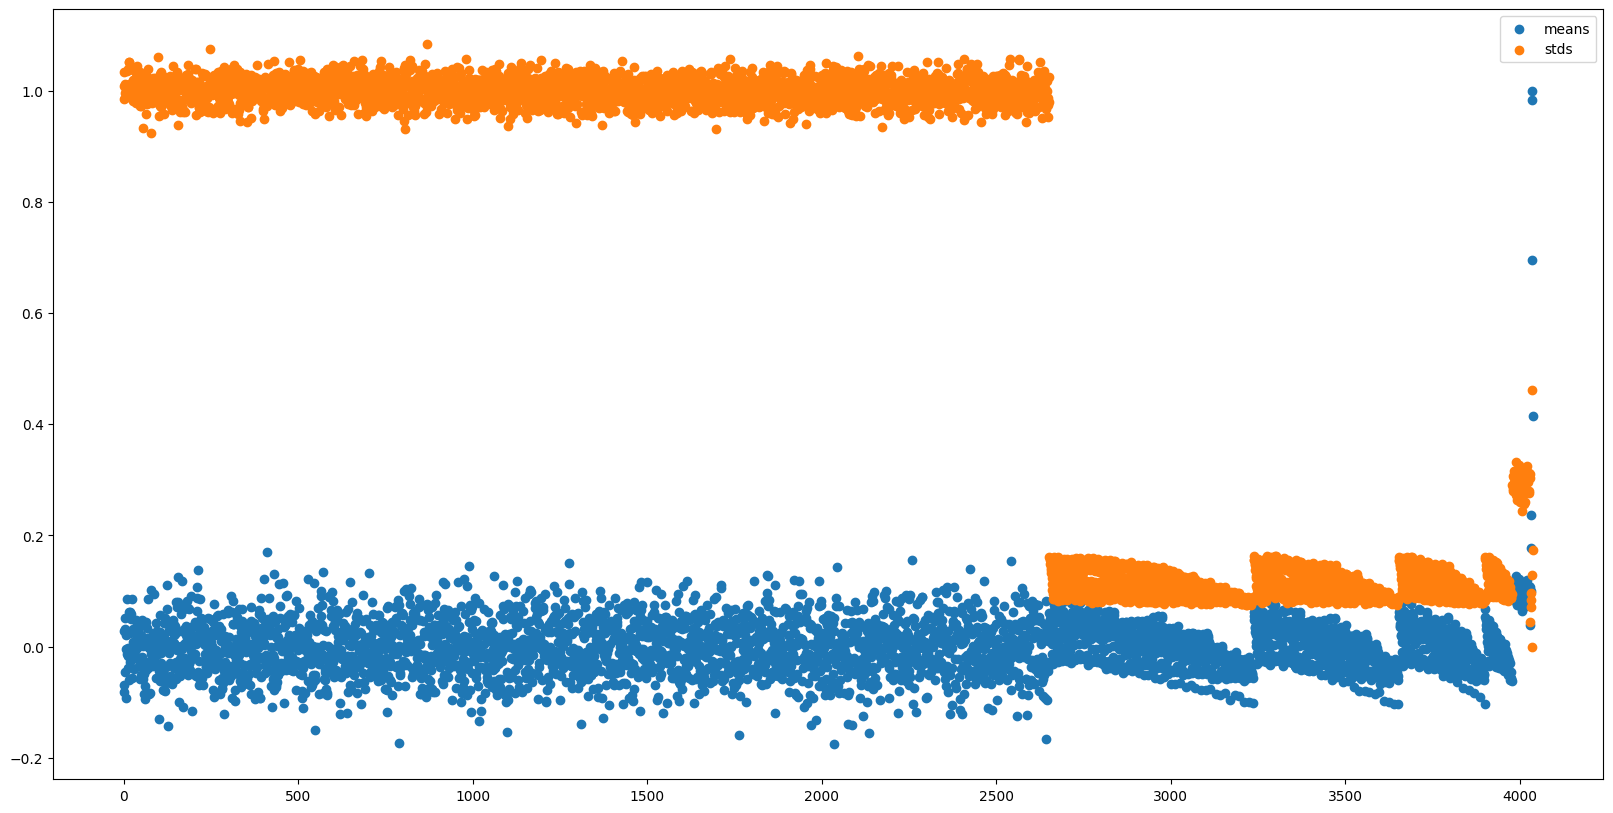

In [373]:
# Check that values are in correct range
fig, ax = plt.subplots(figsize=(20, 10))
plt.scatter(range(df.mean().size), df.mean(), label="means")
plt.scatter(range(df.std().size), df.std(), label="stds")
plt.legend()
plt.show()

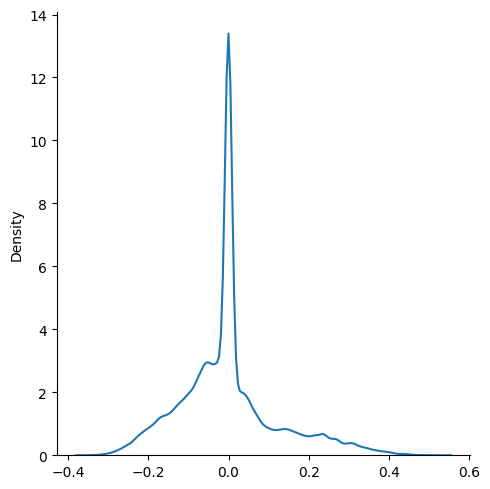

In [374]:
# Plot distribution of output values in a bell curve
from seaborn import displot

displot(raw_df[value_columns].to_numpy().flatten(), kind="kde")
plt.show()


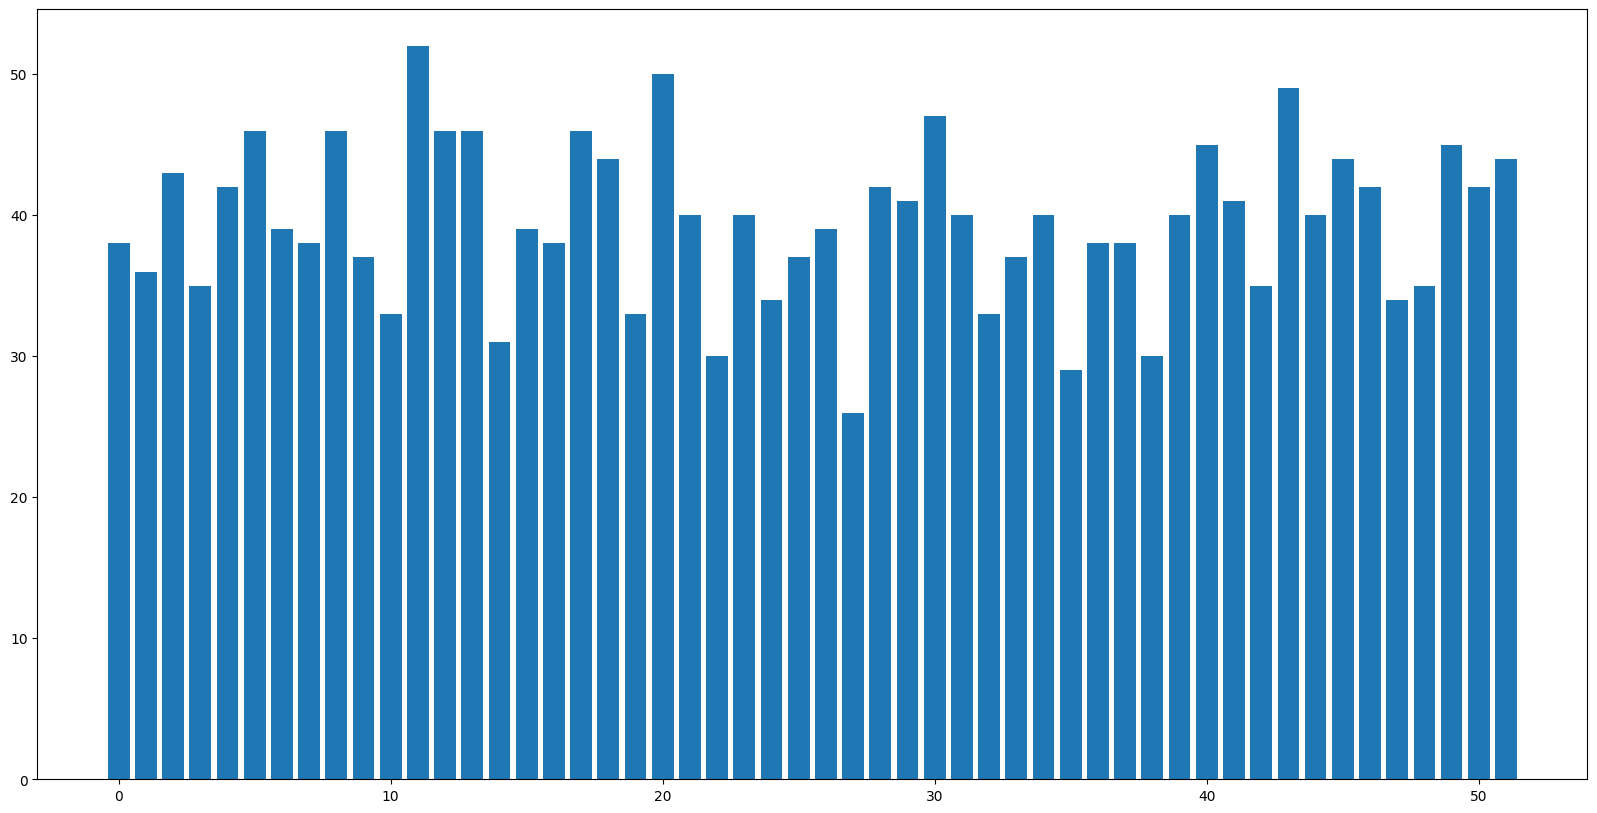

In [375]:
# Check representation of possible public cards
card_cols = [col for col in df.columns if col.startswith("public_card_")]
card_counts = df[card_cols].sum()
fig, ax = plt.subplots(figsize=(20, 10))
plt.bar(range(len(card_counts)), card_counts)
plt.show()

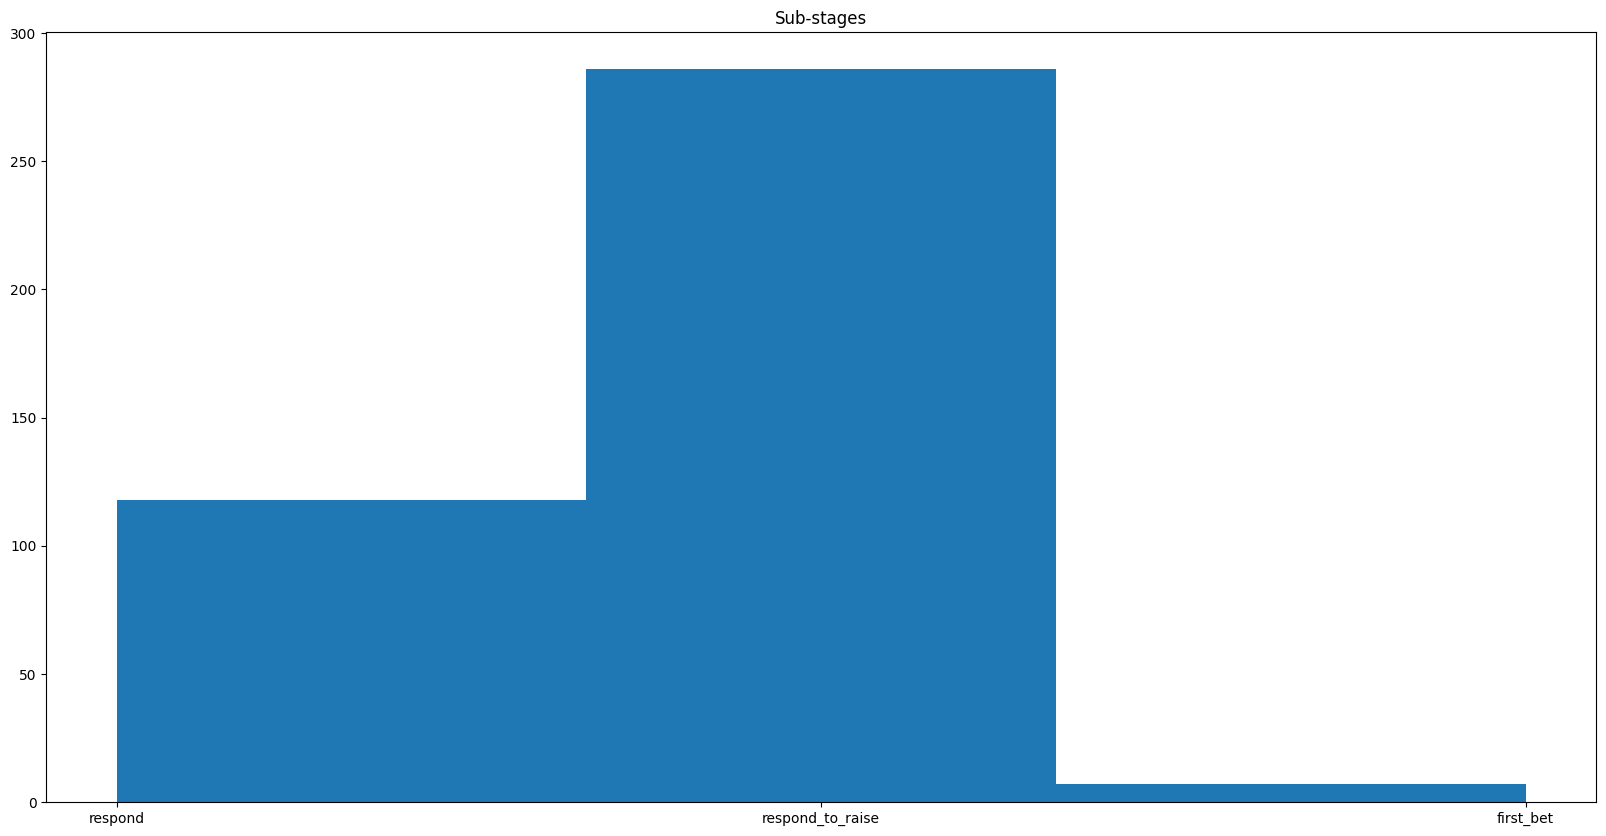

In [376]:
sub_stages = np.where(
    df["player_has_bet"] & df["opponent_has_bet"],
    "respond_to_raise",
    np.where(
        df["opponent_has_bet"],
        "respond",
        "first_bet"
    )
)
fig, ax = plt.subplots(figsize=(20, 10))
plt.hist(sub_stages, bins=3)
plt.title("Sub-stages")
plt.show()

In [377]:
Y_columns = [col for col in df.columns if col.startswith('value_of_hand_')]
X_columns = [col for col in df.columns if col not in Y_columns]
X = df[X_columns].values
Y = df[Y_columns].values
print(X.shape, Y.shape)

(411, 2712) (411, 1326)


### Structure for Neural Network

In [378]:
print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))

Num GPUs Available:  1


In [379]:
def generate_model():
    # Define input layer
    input_layer = Input(shape=(X.shape[1],), name="input_layer")

    # Define hidden layers
    hidden_layer_1 = Dense(128, activation="relu", name="hidden_layer_1")(input_layer)
    hidden_layer_2 = Dense(64, activation="relu", name="hidden_layer_2")(hidden_layer_1)
    hidden_layer_3 = Dense(32, activation="relu", name="hidden_layer_3")(hidden_layer_2)

    # Define value layer for player 1
    value_layer_P1 = Dense(Y.shape[1], activation="linear", name="value_layer_P1")(
        hidden_layer_3
    )

    model = Model(inputs=input_layer, outputs=value_layer_P1)
    model.compile(optimizer='adam', loss='mean_squared_error')

    return model

### Cross validation

In [380]:
# Split the data into training and test sets
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

# Set up K-Fold cross-validation
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# This will store the fold results
fold_results = []

# Define the early stopping callback
early_stopping = EarlyStopping(
    monitor='val_loss',      # Monitor the validation loss
    patience=5,              # Number of epochs with no improvement after which training will be stopped
    verbose=1,               # To print the message when stopping
    restore_best_weights=True  # Restore model weights from the epoch with the best value of the monitored quantity
)

# Loop over each fold
for i, (train_index, val_index) in enumerate(kf.split(X_train)):
    # Split the data into k-fold training and validation sets
    X_train_fold, X_val_fold = X_train[train_index], X_train[val_index]
    Y_train_fold, Y_val_fold = Y_train[train_index], Y_train[val_index]

    print("@@@ FOLD", i+1, "@@@")
    print("Size of training set:", X_train_fold.shape[0])
    
    # Define and compile the neural network inside the loop to reset weights for each fold
    model = generate_model()
    
    # Train the model
    history = model.fit(
        X_train_fold, Y_train_fold,
        epochs=1000,
        validation_data=(X_val_fold, Y_val_fold),
        callbacks=[early_stopping]  # Include the early stopping callback here
    )
    
    # Save the history in fold_results
    fold_results.append(history.history)

@@@ FOLD 1 @@@
Size of training set: 262
Epoch 1/1000


2024-04-29 18:02:02.974159: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


9/9 [==============================] - 1s 97ms/step - loss: 0.1434 - val_loss: 0.1020
Epoch 2/1000


2024-04-29 18:02:03.772254: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


9/9 [==============================] - 0s 16ms/step - loss: 0.0879 - val_loss: 0.0721
Epoch 3/1000
9/9 [==============================] - 0s 14ms/step - loss: 0.0593 - val_loss: 0.0558
Epoch 4/1000
9/9 [==============================] - 0s 14ms/step - loss: 0.0452 - val_loss: 0.0456
Epoch 5/1000
9/9 [==============================] - 0s 15ms/step - loss: 0.0362 - val_loss: 0.0391
Epoch 6/1000
9/9 [==============================] - 0s 13ms/step - loss: 0.0308 - val_loss: 0.0349
Epoch 7/1000
9/9 [==============================] - 0s 15ms/step - loss: 0.0273 - val_loss: 0.0318
Epoch 8/1000
9/9 [==============================] - 0s 11ms/step - loss: 0.0247 - val_loss: 0.0294
Epoch 9/1000
9/9 [==============================] - 0s 12ms/step - loss: 0.0226 - val_loss: 0.0276
Epoch 10/1000
9/9 [==============================] - 0s 15ms/step - loss: 0.0210 - val_loss: 0.0260
Epoch 11/1000
9/9 [==============================] - 0s 15ms/step - loss: 0.0196 - val_loss: 0.0249
Epoch 12/1000
9/9 [==

...

9/9 [==============================] - 1s 109ms/step - loss: 0.1418 - val_loss: 0.1007
Epoch 2/1000
9/9 [==============================] - 0s 20ms/step - loss: 0.0838 - val_loss: 0.0700
Epoch 3/1000
9/9 [==============================] - 0s 15ms/step - loss: 0.0577 - val_loss: 0.0532
Epoch 4/1000
9/9 [==============================] - 0s 19ms/step - loss: 0.0437 - val_loss: 0.0432
Epoch 5/1000
9/9 [==============================] - 0s 13ms/step - loss: 0.0350 - val_loss: 0.0368
Epoch 6/1000
9/9 [==============================] - 0s 14ms/step - loss: 0.0297 - val_loss: 0.0326
Epoch 7/1000
9/9 [==============================] - 0s 16ms/step - loss: 0.0260 - val_loss: 0.0295
Epoch 8/1000
9/9 [==============================] - 0s 12ms/step - loss: 0.0235 - val_loss: 0.0273
Epoch 9/1000
9/9 [==============================] - 0s 12ms/step - loss: 0.0215 - val_loss: 0.0255
Epoch 10/1000
9/9 [==============================] - 0s 21ms/step - loss: 0.0200 - val_loss: 0.0241
Epoch 11/1000
9/9 [==

2024-04-29 18:02:38.744954: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


9/9 [==============================] - 1s 85ms/step - loss: 0.1482 - val_loss: 0.1071


2024-04-29 18:02:39.526847: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


Epoch 2/1000
9/9 [==============================] - 0s 28ms/step - loss: 0.0906 - val_loss: 0.0742
Epoch 3/1000
9/9 [==============================] - 0s 27ms/step - loss: 0.0644 - val_loss: 0.0554
Epoch 4/1000
9/9 [==============================] - 0s 24ms/step - loss: 0.0464 - val_loss: 0.0450
Epoch 5/1000
9/9 [==============================] - 0s 27ms/step - loss: 0.0375 - val_loss: 0.0376
Epoch 6/1000
9/9 [==============================] - 0s 26ms/step - loss: 0.0312 - val_loss: 0.0329
Epoch 7/1000
9/9 [==============================] - 0s 26ms/step - loss: 0.0272 - val_loss: 0.0298
Epoch 8/1000
9/9 [==============================] - 0s 25ms/step - loss: 0.0246 - val_loss: 0.0273
Epoch 9/1000
9/9 [==============================] - 0s 25ms/step - loss: 0.0225 - val_loss: 0.0254
Epoch 10/1000
9/9 [==============================] - 0s 25ms/step - loss: 0.0209 - val_loss: 0.0238
Epoch 11/1000
9/9 [==============================] - 0s 24ms/step - loss: 0.0197 - val_loss: 0.0226
Epoch 12

In [381]:
mse_scores = []

# Evaluate each fold
for fold_history in fold_results:
    val_mse_per_epoch = fold_history['val_loss']
    mse_scores.append(val_mse_per_epoch[-1])  # Take the last epoch MSE

# Calculate the average and standard deviation of the MSE scores across all folds
average_mse = np.mean(mse_scores)
std_dev_mse = np.std(mse_scores)

print(f"Cross-Validation MSE: {average_mse:.4f} (+/- {std_dev_mse:.4f})")
rmse = np.sqrt(average_mse)
rmse_std_dev = np.sqrt(std_dev_mse)
print(f"Cross-Validation RMSE: {rmse:.4f} (+/- {rmse_std_dev:.4f})")

Cross-Validation MSE: 0.0164 (+/- 0.0010)
Cross-Validation RMSE: 0.1281 (+/- 0.0319)


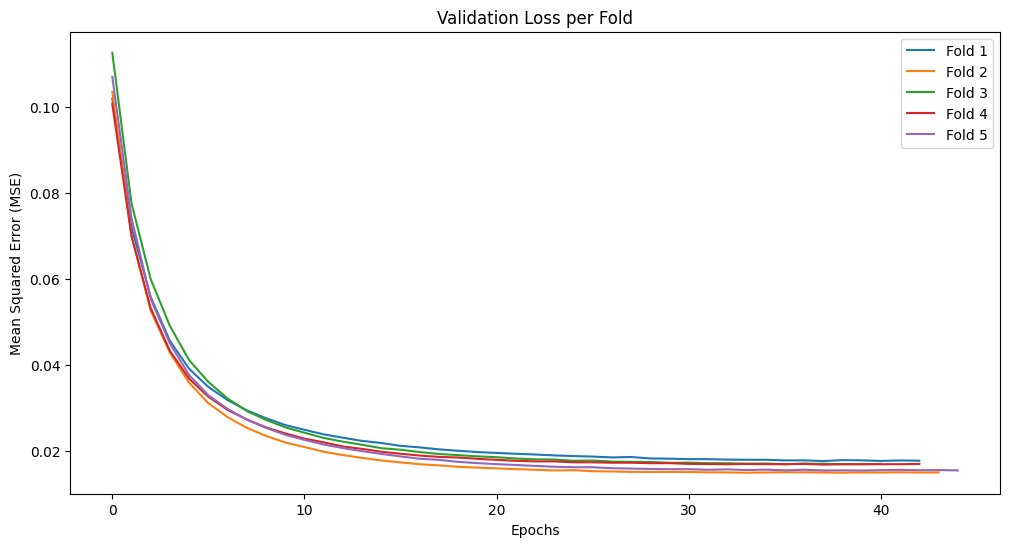

In [382]:
plt.figure(figsize=(12, 6))
for i, fold_history in enumerate(fold_results, 1):
    plt.plot(fold_history['val_loss'], label=f'Fold {i}')

plt.title('Validation Loss per Fold')
plt.xlabel('Epochs')
plt.ylabel('Mean Squared Error (MSE)')
plt.legend()
plt.show()

In [383]:
# Find optimal number of epochs
optimal_epochs = []

for result in fold_results:
    val_loss_per_epoch = result['val_loss']
    best_epoch = val_loss_per_epoch.index(min(val_loss_per_epoch))
    optimal_epochs.append(best_epoch)

average_optimal_epoch = np.mean(optimal_epochs)
buffer = 5  # Add a small buffer to avoid underfitting
final_epoch_number = int(average_optimal_epoch + buffer)

print(f"Suggested number of epochs for final training: {final_epoch_number}")

Suggested number of epochs for final training: 42


### Testing

In [384]:
# Test the model
model = generate_model()
model.fit(X_train, Y_train, epochs=final_epoch_number)
test_loss = model.evaluate(X_test, Y_test)
print(f"Test MSE: {test_loss:.4f}")
print(f"Test RMSE: {np.sqrt(test_loss):.4f}")

Epoch 1/42


2024-04-29 18:02:48.442004: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


11/11 [==============================] - 1s 27ms/step - loss: 0.1364
Epoch 2/42
11/11 [==============================] - 0s 28ms/step - loss: 0.0726
Epoch 3/42
11/11 [==============================] - 0s 18ms/step - loss: 0.0454
Epoch 4/42
11/11 [==============================] - 0s 9ms/step - loss: 0.0349
Epoch 5/42
11/11 [==============================] - 0s 12ms/step - loss: 0.0287
Epoch 6/42
11/11 [==============================] - 0s 9ms/step - loss: 0.0249
Epoch 7/42
11/11 [==============================] - 0s 13ms/step - loss: 0.0224
Epoch 8/42
11/11 [==============================] - 0s 14ms/step - loss: 0.0206
Epoch 9/42
11/11 [==============================] - 0s 10ms/step - loss: 0.0191
Epoch 10/42
11/11 [==============================] - 0s 8ms/step - loss: 0.0179
Epoch 11/42
11/11 [==============================] - 0s 7ms/step - loss: 0.0172
Epoch 12/42
11/11 [==============================] - 0s 7ms/step - loss: 0.0164
Epoch 13/42
11/11 [==============================] - 

2024-04-29 18:02:53.423190: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


### Training of final model

In [386]:
# Train model on all data
model = generate_model()
model.fit(X, Y, epochs=final_epoch_number)

# Change working directory to models
os.chdir("models")

# Save the model
timestamp = datetime.now().strftime("%Y%m%d%H%M%S")
model_fname = f"model_{stage}_{timestamp}.h5"
model.save(model_fname)

# Save metadata
metadata = {
    "mean_training_range_val": mean_training_range_val,
    "sd_training_range_val": sd_training_range_val,
}
meta_fname = f"model_{stage}_{timestamp}.json"
with open(meta_fname, "w") as f:
    json.dump(metadata, f)

# Symlink the model to the latest model
latest_fname = f"model_{stage}_latest.h5"
latest_meta_fname = f"model_{stage}_latest.json"
if os.path.exists(latest_fname):
    os.remove(latest_fname)
if os.path.exists(latest_meta_fname):
    os.remove(latest_meta_fname)
os.symlink(model_fname, latest_fname)
os.symlink(meta_fname, latest_meta_fname)

Epoch 1/42


2024-04-29 18:04:43.483111: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


13/13 [==============================] - 1s 40ms/step - loss: 0.1260
Epoch 2/42
13/13 [==============================] - 0s 25ms/step - loss: 0.0658
Epoch 3/42
13/13 [==============================] - 0s 16ms/step - loss: 0.0395
Epoch 4/42
13/13 [==============================] - 0s 18ms/step - loss: 0.0288
Epoch 5/42
13/13 [==============================] - 0s 14ms/step - loss: 0.0234
Epoch 6/42
13/13 [==============================] - 0s 17ms/step - loss: 0.0203
Epoch 7/42
13/13 [==============================] - 0s 19ms/step - loss: 0.0184
Epoch 8/42
13/13 [==============================] - 0s 16ms/step - loss: 0.0171
Epoch 9/42
13/13 [==============================] - 0s 16ms/step - loss: 0.0162
Epoch 10/42
13/13 [==============================] - 0s 17ms/step - loss: 0.0154
Epoch 11/42
13/13 [==============================] - 0s 21ms/step - loss: 0.0149
Epoch 12/42
13/13 [==============================] - 0s 17ms/step - loss: 0.0144
Epoch 13/42
13/13 [=============================